In [1]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inside notebook
%matplotlib inline

# Improve chart appearance
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Dataset

df = pd.read_csv("../dataset/Dataset for Data Analytics (1).csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display First 5 Rows

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1200, 14)


In [5]:
print("Columns:")
print(df.columns)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [8]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [9]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date converted successfully!")

Date converted successfully!


In [10]:
# Create Month column

df["Month"] = df["Date"].dt.strftime("%B")

df[["Date", "Month"]].head()

,Date,Month
0,2023-01-04,January
1,2024-08-23,August
2,2024-02-27,February
3,2023-10-15,October
4,2025-05-08,May


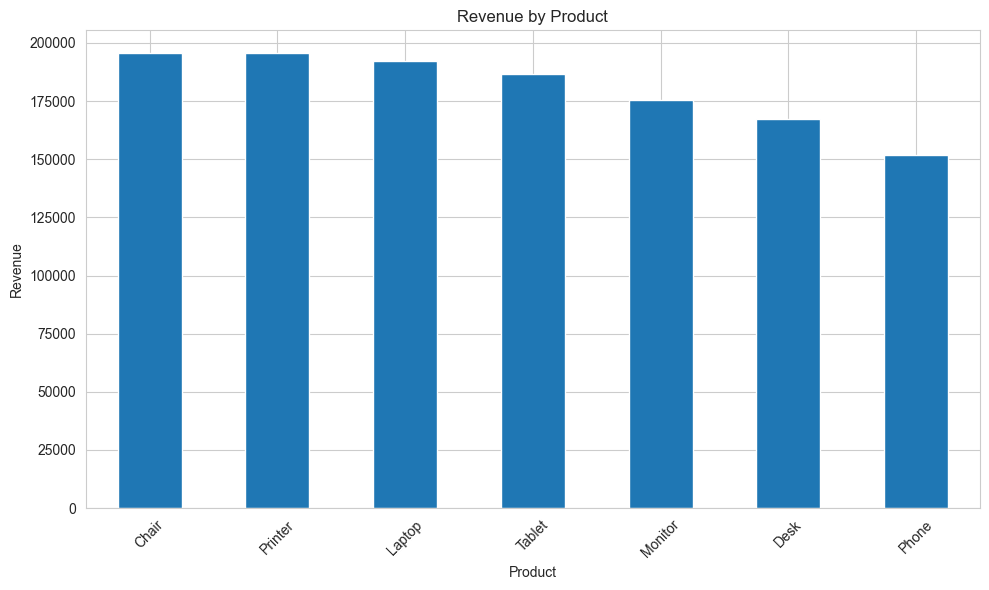

In [12]:
# Revenue by Product

product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
product_sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../output/revenue_by_product.png")
plt.show()

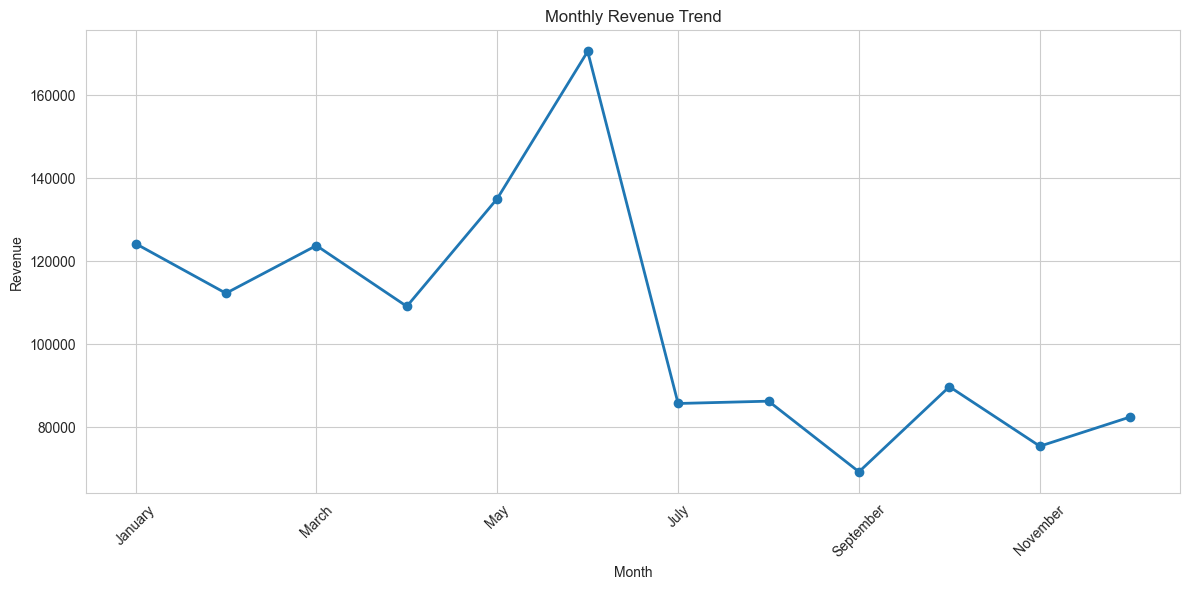

In [13]:
# Monthly Revenue Trend

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

# Arrange months in calendar order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o", linewidth=2)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../output/monthly_sales_trend.png")

plt.show()

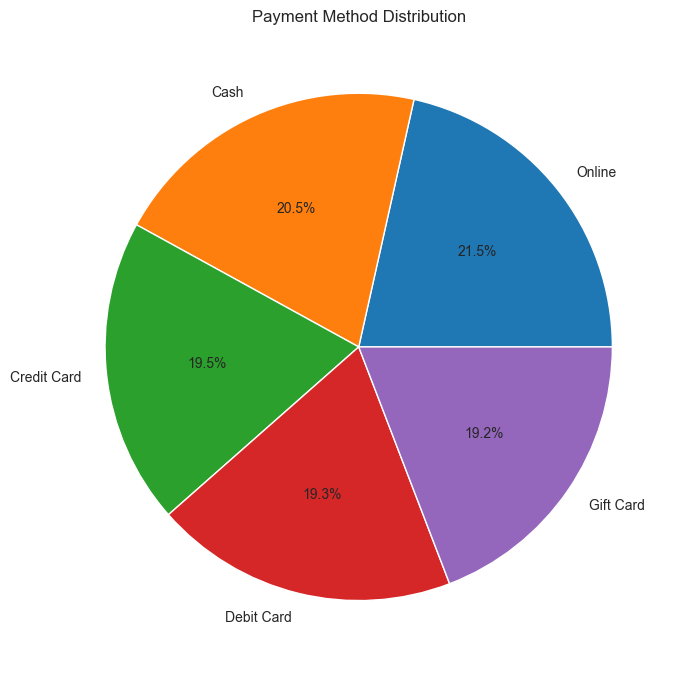

In [14]:
payment = df["PaymentMethod"].value_counts()

plt.figure(figsize=(7,7))

payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.tight_layout()

plt.savefig("../output/payment_method_distribution.png")

plt.show()

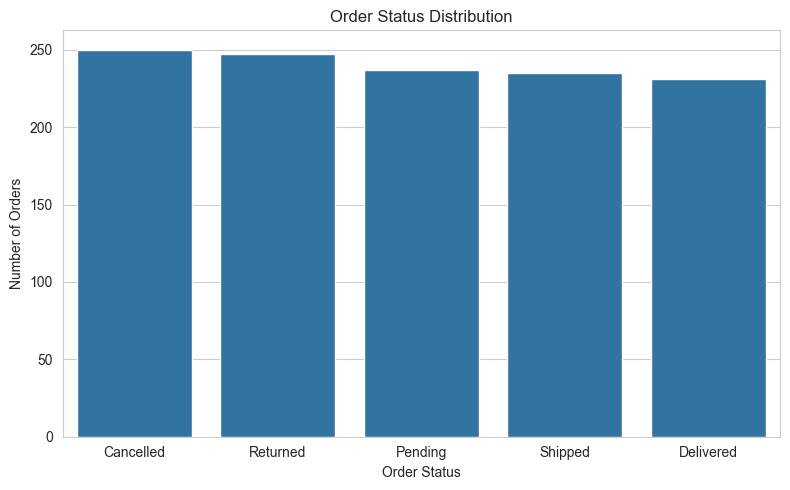

In [15]:
status = df["OrderStatus"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=status.index,
    y=status.values
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("../output/order_status_distribution.png")

plt.show()

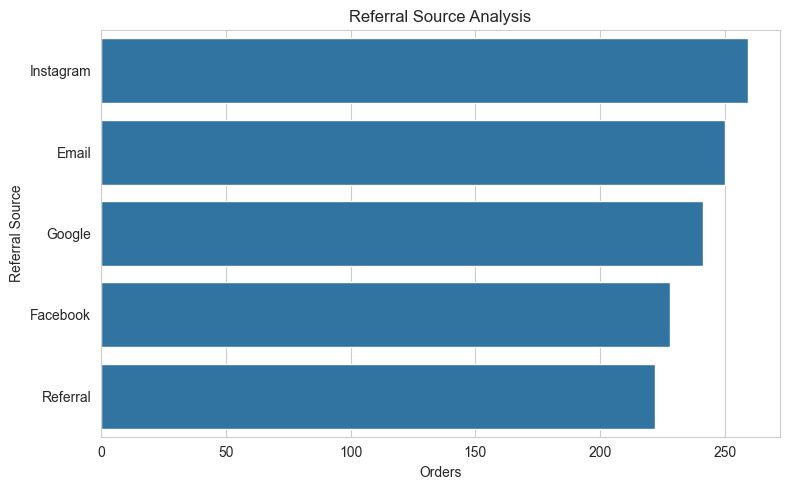

In [16]:
referral = df["ReferralSource"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=referral.values,
    y=referral.index
)

plt.title("Referral Source Analysis")
plt.xlabel("Orders")
plt.ylabel("Referral Source")

plt.tight_layout()

plt.savefig("../output/referral_source_analysis.png")

plt.show()

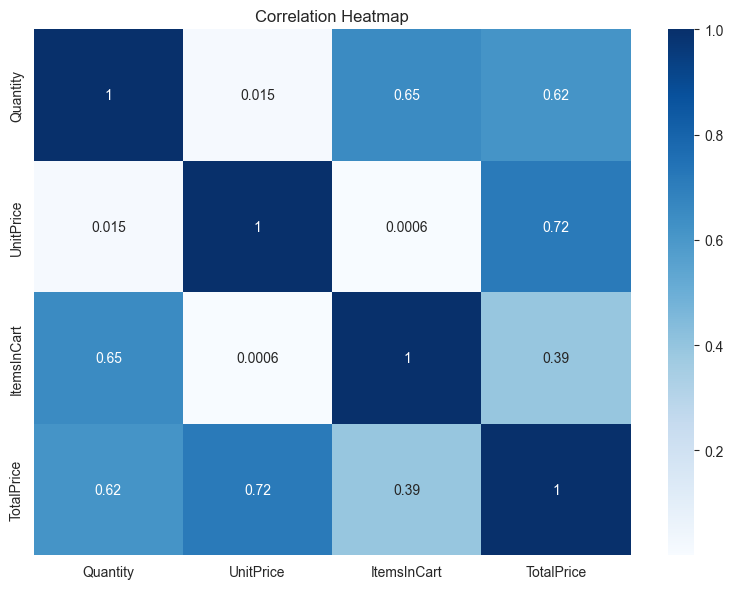

In [17]:
numeric = df[
    [
        "Quantity",
        "UnitPrice",
        "ItemsInCart",
        "TotalPrice"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../output/correlation_heatmap.png")

plt.show()

In [ ]:
# Business Insights

## Revenue by Product
• Tablets and Monitors generated the highest revenue among all products.
• Phones contributed the least revenue compared to other products.

## Monthly Revenue Trend
• Revenue varied across different months.
• Certain months recorded noticeably higher sales, indicating seasonal demand.

## Payment Method Distribution
• Customers preferred online payment methods over others.
• The distribution suggests multiple payment options are actively used.

## Order Status Distribution
• Most orders were successfully completed.
• A smaller proportion of orders were cancelled or returned.

## Referral Source Analysis
• Referral channels contributed differently to customer acquisition.
• Some marketing sources generated significantly more orders than others.

## Correlation Analysis
• Total Price has a strong positive correlation with Unit Price.
• Quantity also shows a positive relationship with Total Price.
• Items in Cart has a moderate correlation with Total Price.